# 📊 NetworkX Fundamentals & Graph Theory

**Course:** Community Detection & Graph Analysis  
**Notebook:** 01 — NetworkX Basics  

---

This notebook is a structured introduction to graph theory using Python's **NetworkX** library. We progress from basic graph construction through to structural analysis, centrality, and spanning trees.

Each section follows the pattern:  
> **Theory → Example Graph → Code → Interpretation**

All heavy computation lives in `src/`; this notebook focuses on understanding concepts.

---

**Table of Contents**
1. [Graph Fundamentals](#section-1)
2. [Graph Representations & Laplacian](#section-2)
3. [Extracting Information from Graphs](#section-3)
4. [Shortest Path Algorithms](#section-4)
5. [Centrality Measures](#section-5)
6. [Bridges & Community Structure](#section-6)
7. [Diameter, Density & Eulerian Properties](#section-7)
8. [Cliques, Connectivity & Bridges](#section-8)
9. [Spanning Trees & Connected Components](#section-9)

In [ ]:
# ── Standard imports ──────────────────────────────────────────────────────────
import sys
import os

# Add project root to path so we can import from src/
sys.path.insert(0, os.path.abspath('..'))

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Project modules ───────────────────────────────────────────────────────────
from src.graph_creation_01     import (create_simple_graph, create_directed_graph,
                                      create_weighted_graph, create_multigraph,
                                      create_karate_club_graph,
                                      create_two_cliques_with_bridge,
                                      create_eulerian_graph,
                                      create_spanning_tree_graph)
from src.graph_visualization_03 import (draw_simple_graph, draw_weighted_graph,
                                      draw_directed_graph, draw_multiple_layouts,
                                      draw_centrality, draw_bridge_graph,
                                      draw_spanning_tree, draw_components)
from src.graph_metrics_02       import (print_matrices, print_graph_info,
                                      get_degree_info, get_neighbors,
                                      get_adjacency_list, get_edge_list,
                                      graph_diameter, graph_density, check_eulerian)
from src.centrality_measures_04 import (centrality_summary, top_nodes_by_centrality,
                                      degree_centrality, betweenness_centrality)
from src.connectivity_analysis_05 import (find_all_cliques, find_largest_clique,
                                        print_clique_info, get_connected_components,
                                        find_bridges, find_articulation_points,
                                        remove_edge_and_check)
from src.shortest_paths_06      import (shortest_path, shortest_path_length,
                                      print_path_info, draw_shortest_path)

# ── Matplotlib settings ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'    : 120,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.spines.left'   : False,
    'axes.spines.bottom' : False,
})

print('✓ All imports successful.')

✓ All imports successful.


---
<a id='section-1'></a>
## Section 1 — Graph Fundamentals

### What is a Graph?

A **graph** $G = (V, E)$ consists of:
- **Vertices (nodes)** $V$ — entities (people, cities, web pages, …)
- **Edges** $E$ — relationships between entities

NetworkX supports four graph types:

| Class | Edges | Multiple edges? |
|---|---|---|
| `Graph` | undirected | No |
| `DiGraph` | directed | No |
| `MultiGraph` | undirected | Yes |
| `MultiDiGraph` | directed | Yes |

### 1.1 — Creating and Drawing a Simple Graph

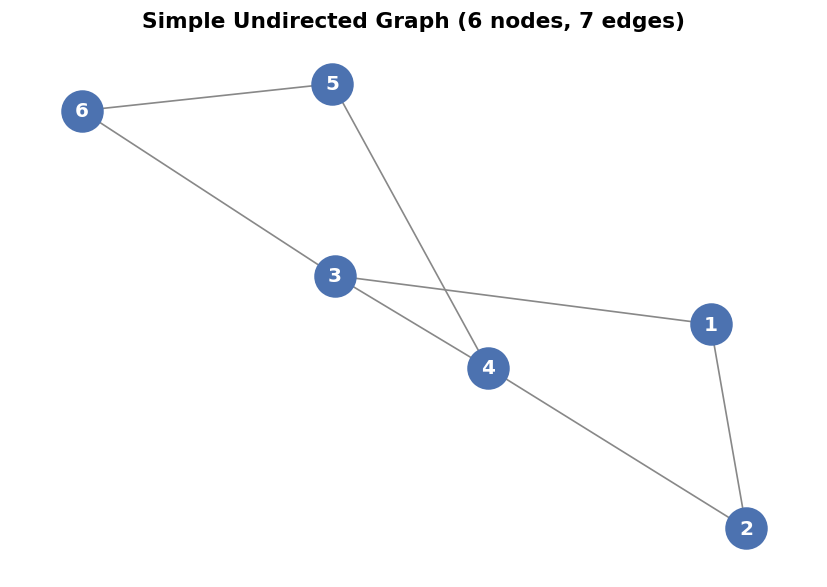

Nodes : [1, 2, 3, 4, 5, 6]
Edges : [(1, 2), (1, 3), (2, 4), (3, 4), (3, 6), (4, 5), (5, 6)]


In [3]:
# Create a simple 6-node undirected graph
G = create_simple_graph()

fig, ax = plt.subplots(figsize=(7, 5))

draw_simple_graph(
    G,
    title="Simple Undirected Graph (6 nodes, 7 edges)",
    ax=ax
)

plt.tight_layout()

# Save image to images folder
plt.savefig("../images/simple_undirected_graph.png")

plt.show()

print(f'Nodes : {list(G.nodes())}')
print(f'Edges : {list(G.edges())}')

> **Interpretation:** Each circle is a node. Lines are edges. There is no direction — the relationship is symmetric (e.g., friendship).

### 1.2 — Directed Graph (DiGraph)

In a **directed graph**, edges have direction. If A → B, it does *not* imply B → A.  
Useful for modelling: web links, citation networks, information flow.

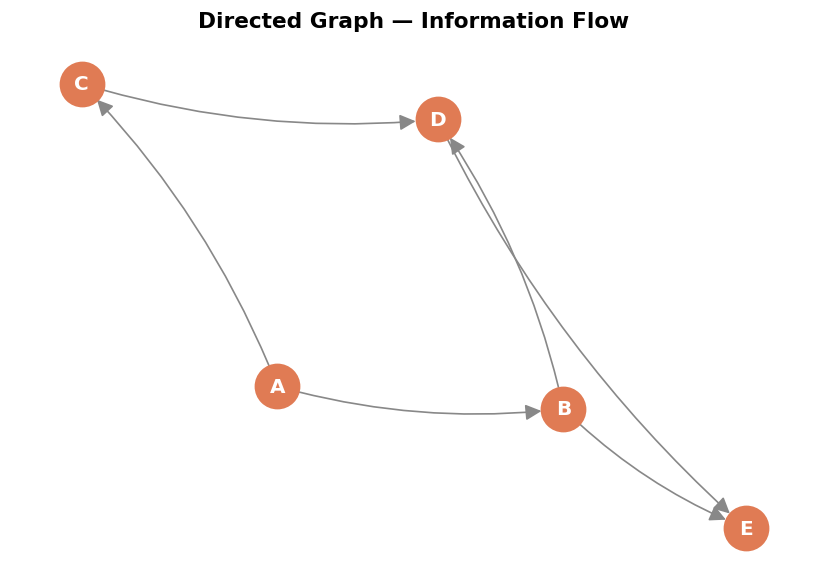

Directed edges: [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'D'), ('D', 'E')]


In [4]:
DG = create_directed_graph()

fig, ax = plt.subplots(figsize=(7, 5))
draw_directed_graph(DG, title="Directed Graph — Information Flow", ax=ax)
plt.tight_layout()
plt.savefig("../images/simple_directed_graph.png")
plt.show()

print(f'Directed edges: {list(DG.edges())}')

### 1.3 — Weighted Graph

**Weights** on edges encode quantities like distance, cost, bandwidth, or similarity.

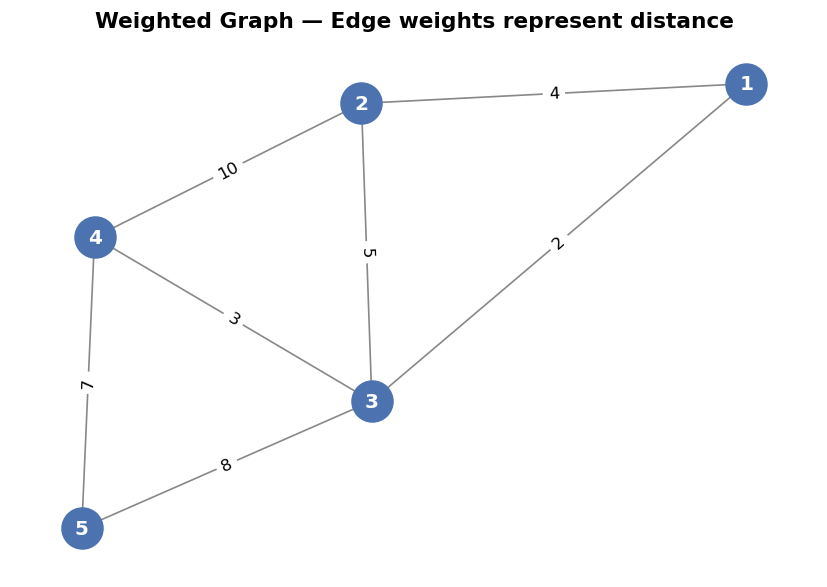

<Figure size 768x576 with 0 Axes>

In [5]:
WG = create_weighted_graph()

draw_weighted_graph(WG, title="Weighted Graph — Edge weights represent distance")
plt.savefig("../images/simple_weighted_graph.png")
plt.show()

### 1.4 — MultiGraph

A **MultiGraph** allows multiple edges between the same pair of nodes.  
Example: two cities can have multiple flight routes.

C:\Users\saisi\AppData\Local\Temp\ipykernel_28652\2981748851.py:24: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


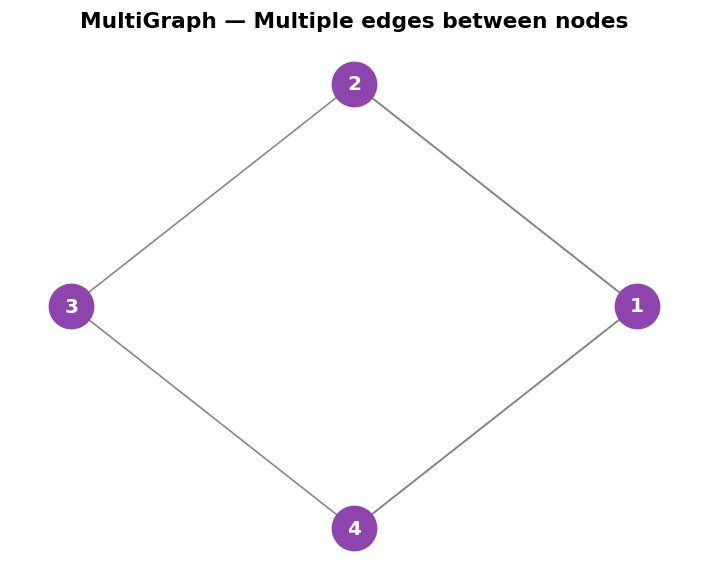

Number of edges (with multiples): 6


In [6]:
MG = create_multigraph()

fig, ax = plt.subplots(figsize=(6, 5))

pos = nx.circular_layout(MG)

nx.draw_networkx_nodes(
    MG,
    pos,
    ax=ax,
    node_color='#8E44AD',
    node_size=700
)

nx.draw_networkx_labels(
    MG,
    pos,
    ax=ax,
    font_color='white',
    font_weight='bold'
)

# Draw edges separately with curved lines
nx.draw_networkx_edges(
    MG,
    pos,
    ax=ax,
    edge_color='#888',
    connectionstyle='arc3,rad=0.2'
)

ax.set_title(
    'MultiGraph — Multiple edges between nodes',
    fontsize=13,
    fontweight='bold'
)

ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Number of edges (with multiples): {MG.number_of_edges()}')

---
<a id='section-2'></a>
## Section 2 — Graph Representations & Laplacian Matrix

Graphs can be represented mathematically using matrices. The three key matrices are:

| Matrix | Symbol | Definition |
|--------|--------|------------|
| Adjacency | $A$ | $A_{ij} = 1$ if edge $(i,j)$ exists |
| Degree | $D$ | Diagonal; $D_{ii} = \deg(i)$ |
| Laplacian | $L$ | $L = D - A$ |

The **Laplacian** is fundamental in spectral graph theory. Its eigenvalues encode connectivity: the number of zero eigenvalues equals the number of connected components.

### 2.1 — Matrix Representations

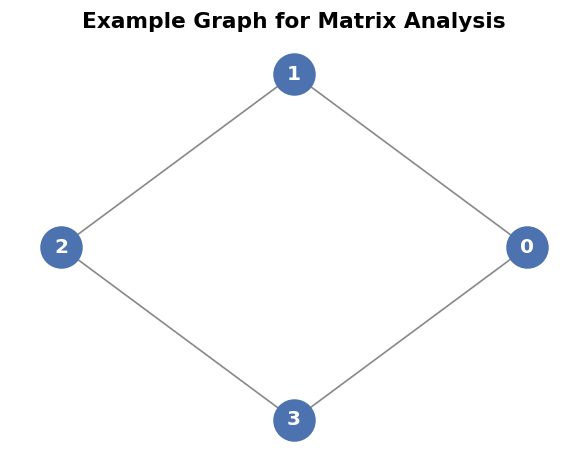

Adjacency Matrix (A):
   0  1  2  3
0  0  1  0  1
1  1  0  1  0
2  0  1  0  1
3  1  0  1  0

Degree Matrix (D):
   0  1  2  3
0  2  0  0  0
1  0  2  0  0
2  0  0  2  0
3  0  0  0  2

Laplacian Matrix (L = D − A):
   0  1  2  3
0  2 -1  0 -1
1 -1  2 -1  0
2  0 -1  2 -1
3 -1  0 -1  2


In [7]:
# Use a small 4-node graph for clarity
G_small = nx.cycle_graph(4)   # square: 0-1-2-3-0

fig, ax = plt.subplots(figsize=(5, 4))
draw_simple_graph(G_small, title='Example Graph for Matrix Analysis',
                  layout='circular', ax=ax)
plt.tight_layout()
plt.show()

print_matrices(G_small)

> **Key insight:** Each row of L sums to zero. The diagonal entry $L_{ii}$ is the degree of node $i$; off-diagonal entries $L_{ij} = -1$ if edge exists, else 0.

### 2.2 — Graph Layout Comparison

NetworkX offers several layout algorithms that position nodes differently.  
The **structure** of the graph is identical — only the visual arrangement changes.

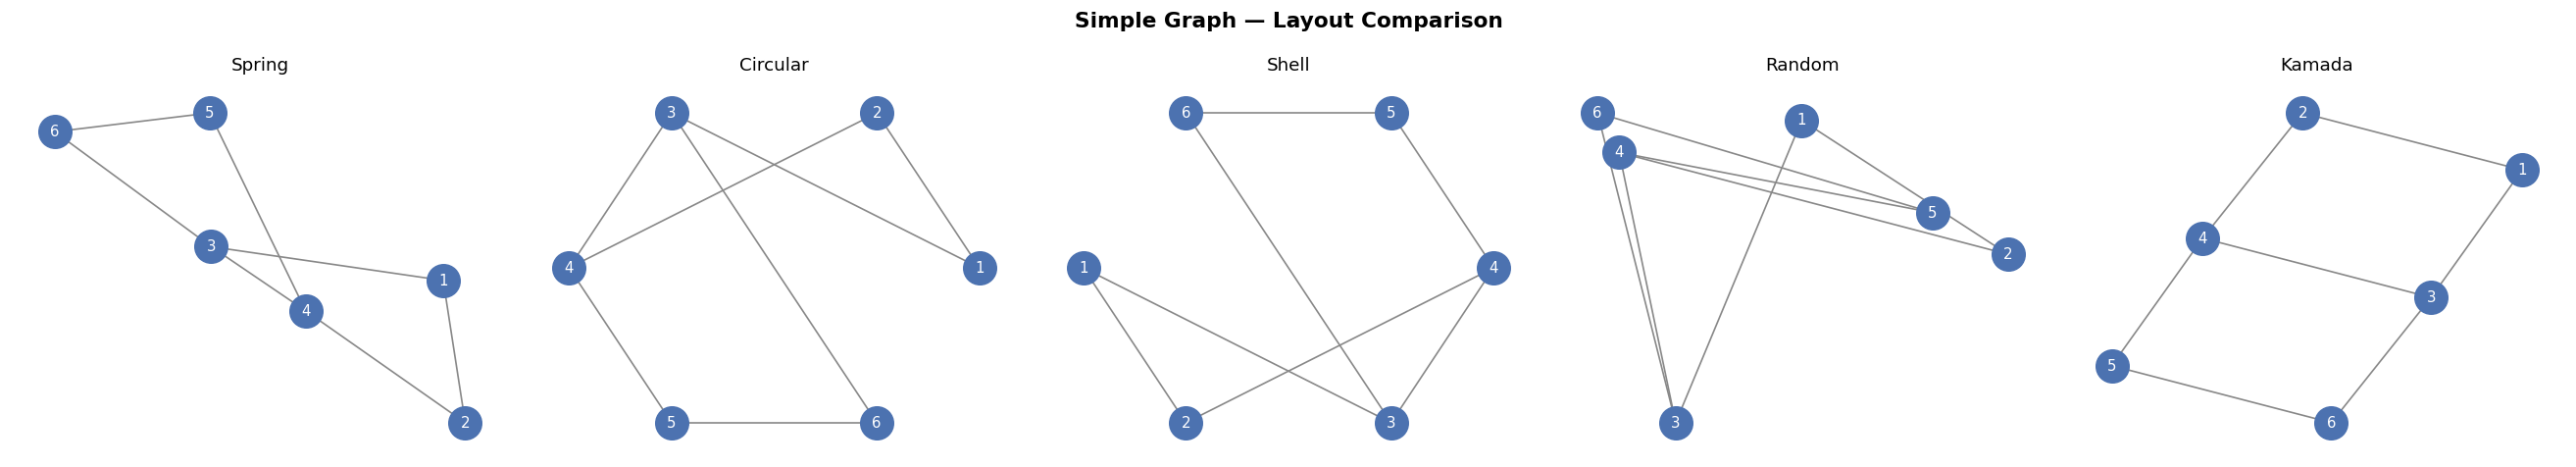

In [8]:
G_layout = create_simple_graph()

draw_multiple_layouts(
    G_layout,
    title_prefix='Simple Graph',
    save_path="../images/layout_comparison.png"
)

> **When to use each layout:**  
> - **Spring** — general purpose; mimics physical force simulation  
> - **Circular** — good for showing degree distribution  
> - **Shell** — useful for hierarchical or layered graphs  
> - **Planar** — avoids crossing edges (only for planar graphs)  
> - **Random** — fast but unstructured

---
<a id='section-3'></a>
## Section 3 — Extracting Information from a Graph

NetworkX provides rich APIs to query structural properties. We will use the **Zachary Karate Club** graph — a famous real-world social network from 1977 with 34 members and 78 friendships.

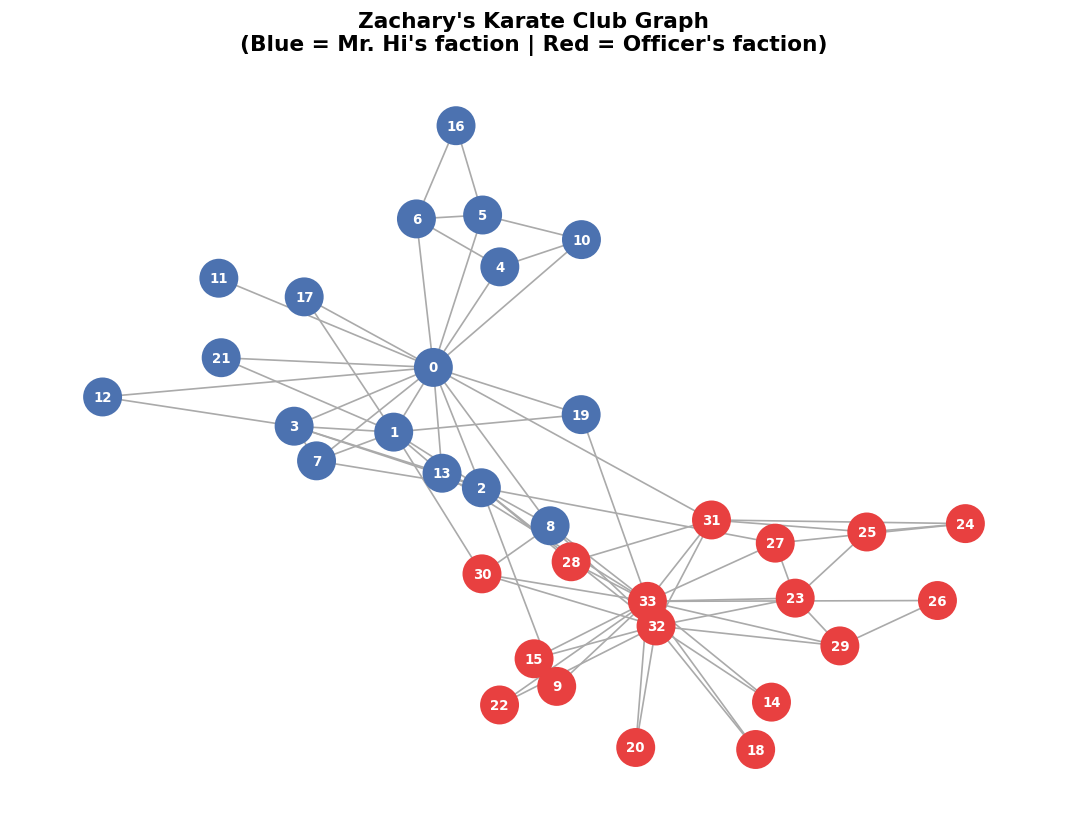

In [9]:
K = create_karate_club_graph()

fig, ax = plt.subplots(figsize=(9, 7))
pos = nx.spring_layout(K, seed=42)

# Colour by club label (stored as node attribute)
node_colors = ['#E84040' if K.nodes[n]['club'] == 'Officer'
               else '#4C72B0' for n in K.nodes()]

nx.draw_networkx(K, pos, ax=ax,
                 node_color=node_colors, node_size=500,
                 font_size=8, font_color='white', font_weight='bold',
                 edge_color='#aaa')
ax.set_title("Zachary's Karate Club Graph\n(Blue = Mr. Hi's faction | Red = Officer's faction)",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig("../images/zachary's_karate_club_graph.png")
plt.show()

In [10]:
# ── Basic statistics ──────────────────────────────────────────────────────────
print_graph_info(K, name="Zachary's Karate Club")

  Zachary's Karate Club
  Nodes          : 34
  Edges          : 78
  Directed       : False
  Weighted       : True
  Diameter       : 5
  Density        : 0.1390


In [11]:
# ── Degree of each node ───────────────────────────────────────────────────────
degree_list = get_degree_info(K)
print('Top 10 nodes by degree:')
for node, deg in degree_list[:10]:
    print(f'  Node {node:2d}  →  degree {deg}')

Top 10 nodes by degree:
  Node 33  →  degree 17
  Node  0  →  degree 16
  Node 32  →  degree 12
  Node  2  →  degree 10
  Node  1  →  degree 9
  Node  3  →  degree 6
  Node 31  →  degree 6
  Node  8  →  degree 5
  Node 13  →  degree 5
  Node 23  →  degree 5


In [12]:
# ── Neighbours of node 0 ──────────────────────────────────────────────────────
print(f'Neighbours of node 0: {get_neighbors(K, 0)}')

# ── Edge list (first 10) ──────────────────────────────────────────────────────
edges = get_edge_list(K)
print(f'\nTotal edges: {len(edges)}')
print(f'First 10:    {edges[:10]}')

Neighbours of node 0: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]

Total edges: 78
First 10:    [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11)]


In [13]:
# ── Adjacency list (first 6 nodes) ────────────────────────────────────────────
adj = get_adjacency_list(K)
print('Adjacency list (first 6 nodes):')
for node in list(adj.keys())[:6]:
    print(f'  {node:2d} → {adj[node]}')

Adjacency list (first 6 nodes):
   0 → [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
   1 → [0, 2, 3, 7, 13, 17, 19, 21, 30]
   2 → [0, 1, 3, 7, 8, 9, 13, 27, 28, 32]
   3 → [0, 1, 2, 7, 12, 13]
   4 → [0, 6, 10]
   5 → [0, 6, 10, 16]


> **Interpretation:** Node 0 (club president) and node 33 (instructor) have the highest degree, as expected in a social network where leaders know many people.

---
<a id='section-4'></a>
## Section 4 — Shortest Path Algorithms

The **shortest path** between two nodes is the path with the fewest edges (unweighted) or minimum total weight (weighted).

NetworkX uses **Dijkstra's algorithm** for weighted graphs (non-negative weights) and **BFS** for unweighted graphs.

$$\text{path}(s, t) = \arg\min_{p} \sum_{e \in p} w(e)$$

### 4.1 — Unweighted Shortest Path

Shortest path  (1 → 6): 1 → 3 → 6
Path length (hops)             : 2


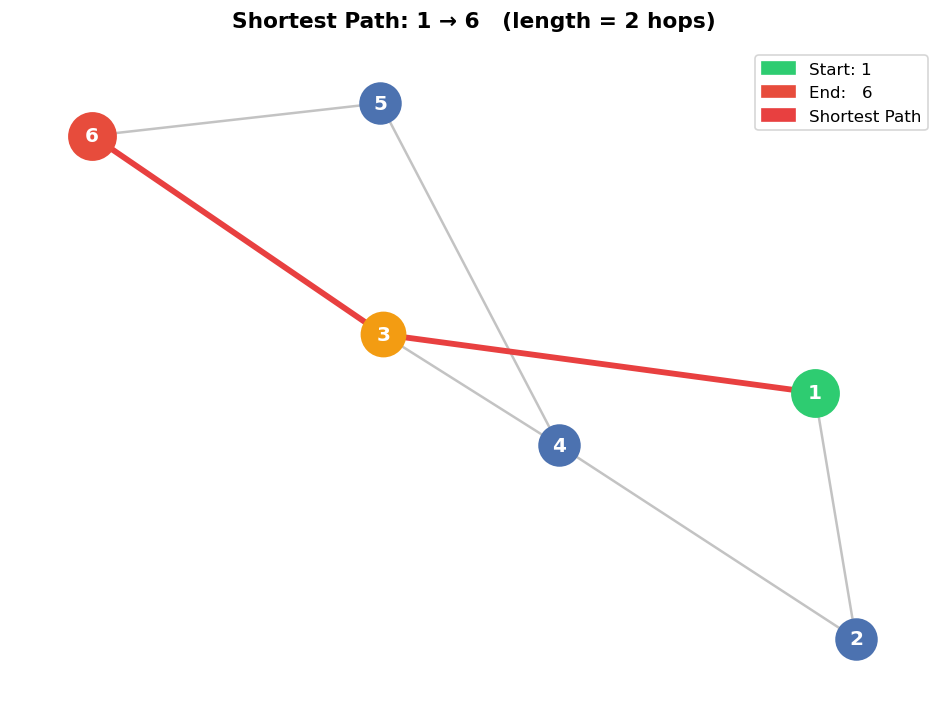

In [14]:
G = create_simple_graph()

# Find path from node 1 to node 6
print_path_info(G, source=1, target=6)

draw_shortest_path(G, source=1, target=6)

### 4.2 — Weighted Shortest Path (Dijkstra)

Unweighted path (fewest hops):
Shortest path  (1 → 5): 1 → 3 → 5
Path length (hops)             : 2

Weighted path (minimum total distance):
Shortest path  (1 → 5): 1 → 3 → 5
Path length (weight)             : 10


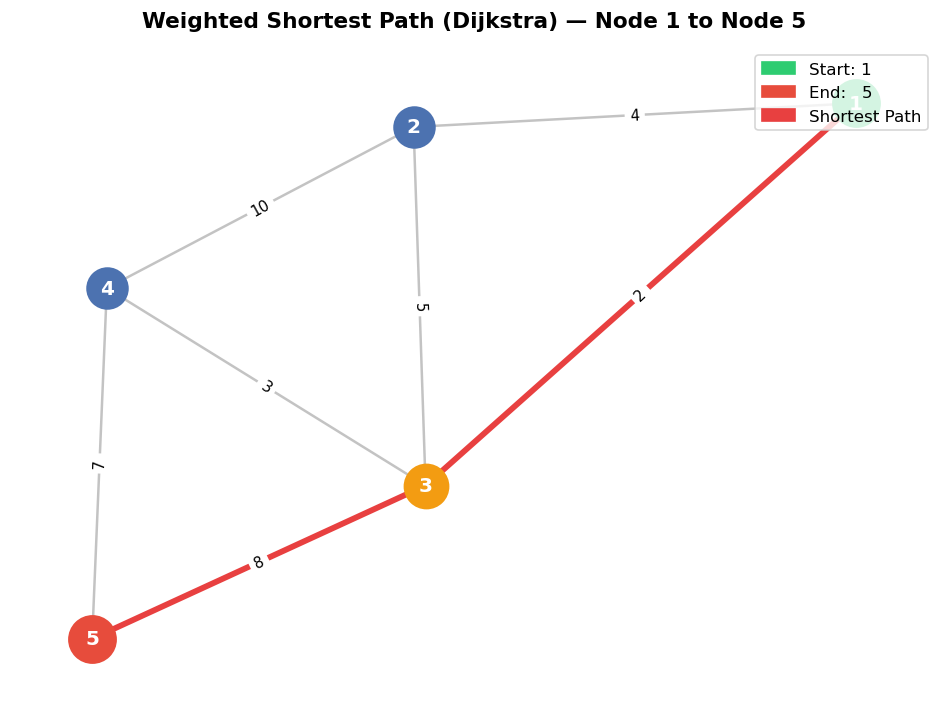

In [15]:
WG = create_weighted_graph()

print('Unweighted path (fewest hops):')
print_path_info(WG, source=1, target=5, weight=None)

print('\nWeighted path (minimum total distance):')
print_path_info(WG, source=1, target=5, weight='weight')

draw_shortest_path(WG, source=1, target=5, weight='weight',
                   title='Weighted Shortest Path (Dijkstra) — Node 1 to Node 5')

> **Interpretation:** The weighted path may take more hops but a lower total cost. This is analogous to navigation apps choosing a longer road to avoid traffic.

---
<a id='section-5'></a>
## Section 5 — Centrality Measures

**Centrality** quantifies how *important* a node is within a network.  
Different measures capture different aspects of importance:

| Measure | Captures |
|---|---|
| Degree | Raw connectivity |
| Closeness | Efficiency of spreading |
| Betweenness | Control over information flow |
| Eigenvector | Prestige / influential neighbours |

In [16]:
K = create_karate_club_graph()

# Full centrality comparison table
df_centrality = centrality_summary(K)
print('Centrality Summary — Top 10 nodes by Betweenness:')
print(df_centrality.head(10).to_string())

Centrality Summary — Top 10 nodes by Betweenness:
      Degree  Closeness  Betweenness  Eigenvector
Node                                             
0     0.4848     0.5690       0.4376       0.3555
33    0.5152     0.5500       0.3041       0.3734
32    0.3636     0.5156       0.1452       0.3087
2     0.3030     0.5593       0.1437       0.3172
31    0.1818     0.5410       0.1383       0.1910
8     0.1515     0.5156       0.0559       0.2274
1     0.2727     0.4853       0.0539       0.2660
13    0.1515     0.5156       0.0459       0.2265
19    0.0909     0.5000       0.0325       0.1479
5     0.1212     0.3837       0.0300       0.0795


### 5.1 — Degree Centrality
Simply the fraction of all other nodes a node is directly connected to.  
$$C_D(v) = \frac{\deg(v)}{n - 1}$$

Top 5 nodes by Degree Centrality:
  Node 33: 0.5152
  Node  0: 0.4848
  Node 32: 0.3636
  Node  2: 0.3030
  Node  1: 0.2727


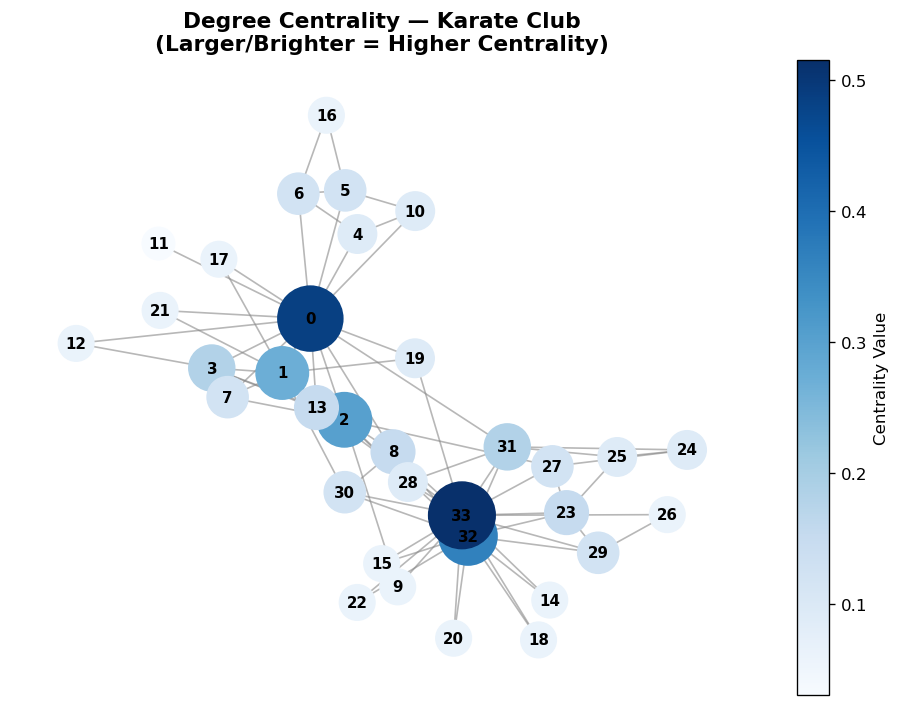

<Figure size 768x576 with 0 Axes>

In [17]:

dc = degree_centrality(K)

print('Top 5 nodes by Degree Centrality:')

for node, val in sorted(
    dc.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]:

    print(f'  Node {node:2d}: {val:.4f}')

draw_centrality(
    K,
    dc,
    title='Degree Centrality — Karate Club\n(Larger/Brighter = Higher Centrality)',
    cmap='Blues'
)

# Save current figure
plt.savefig(
    "../images/degree_centrality_karate_club.png",
    dpi=300,
    bbox_inches='tight'
)

### 5.2 — Betweenness Centrality
Fraction of all shortest paths (between any two nodes) that pass through node $v$.  
High betweenness → the node acts as a **bridge** or **broker**.

Top 5 nodes by Betweenness Centrality:
  Node  0: 0.4376
  Node 33: 0.3041
  Node 32: 0.1452
  Node  2: 0.1437
  Node 31: 0.1383


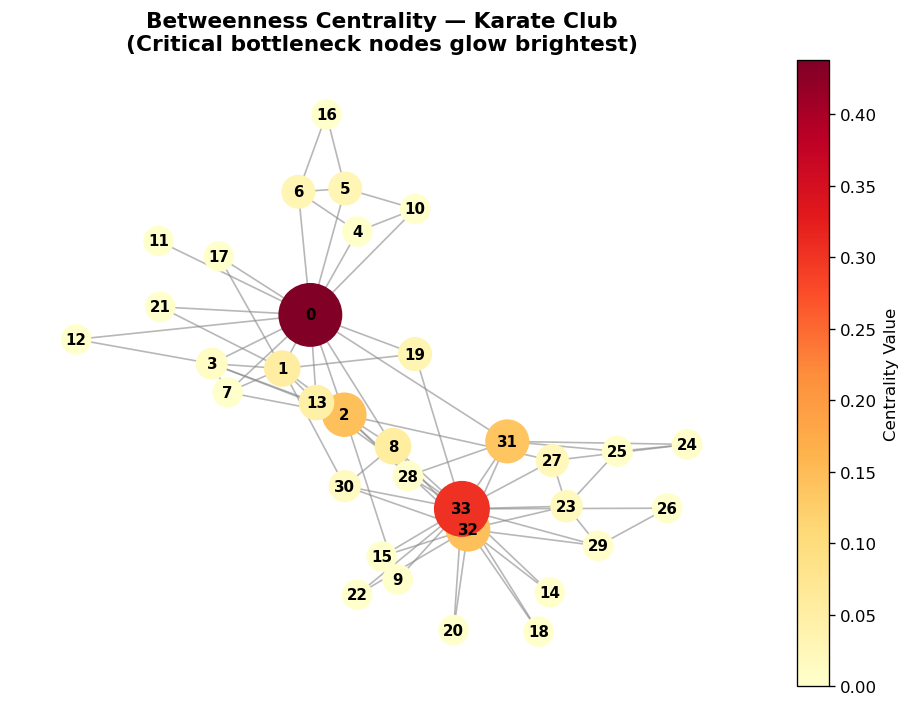

<Figure size 768x576 with 0 Axes>

In [18]:
bc = betweenness_centrality(K)

print('Top 5 nodes by Betweenness Centrality:')

for node, val in sorted(
    bc.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]:

    print(f'  Node {node:2d}: {val:.4f}')

draw_centrality(
    K,
    bc,
    title='Betweenness Centrality — Karate Club\n(Critical bottleneck nodes glow brightest)',
    cmap='YlOrRd'
)

# Save current figure
fig = plt.gcf()

fig.savefig(
    "../images/betweenness_centrality_karate_club.png",
    dpi=300,
    bbox_inches='tight'
)

> **Interpretation:** Nodes 0 and 33 (the two club leaders) dominate betweenness centrality. They sit on paths between the two factions — exactly where we expect the network's connective tissue to lie.

---
<a id='section-6'></a>
## Section 6 — Bridges & Community Structure

### What is a Bridge?

A **bridge** is an edge whose removal *disconnects* the graph.  
In social networks, bridges often connect distinct communities — they are critical links.

**K₅ (Complete graph on 5 nodes)** — every node connects to every other, making it a tight community (clique).

Here we build two K₅ communities and connect them with a single bridge edge.

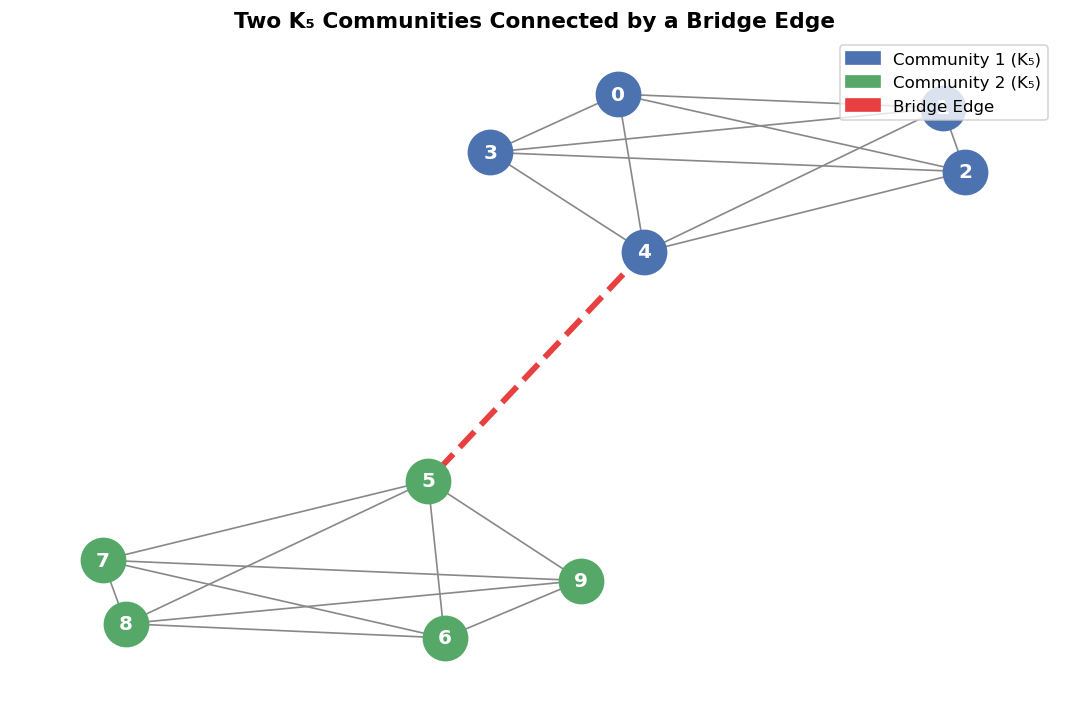

In [19]:
G_bridge = create_two_cliques_with_bridge()

# The bridge is the edge connecting the two K5s
bridge_edge = (4, 5)

draw_bridge_graph(G_bridge, bridge_edge,
                  title='Two K₅ Communities Connected by a Bridge Edge')

In [20]:
# Verify the bridge
bridges = find_bridges(G_bridge)
art_pts  = find_articulation_points(G_bridge)

print(f'Bridge edges        : {bridges}')
print(f'Articulation points : {art_pts}')
print()
print('Effect of removing the bridge:')
_ = remove_edge_and_check(G_bridge, bridge_edge)

Bridge edges        : [(4, 5)]
Articulation points : [5, 4]

Effect of removing the bridge:
Removed edge: (4, 5)
Components before removal: 1
Components after  removal: 2
  ⚠ This was a bridge — graph is now disconnected!


> **Insight:** Removing the single edge (4, 5) splits the graph into two disconnected K₅ cliques. This is exactly how real communities form — tight internal connections with sparse inter-community links.

---
<a id='section-7'></a>
## Section 7 — Diameter, Density & Eulerian Properties

| Property | Definition |
|---|---|
| **Diameter** | Longest shortest path in the graph |
| **Density** | Ratio of actual edges to maximum possible edges |
| **Eulerian Circuit** | Visits every edge exactly once, returns to start |
| **Eulerian Path** | Visits every edge exactly once (no return required) |

In [21]:
G = create_simple_graph()

print(f'Graph diameter : {graph_diameter(G)}')
print(f'Graph density  : {graph_density(G):.4f}')
print()

# Karate club for comparison
K = create_karate_club_graph()
print(f'Karate Club diameter : {graph_diameter(K)}')
print(f'Karate Club density  : {graph_density(K):.4f}')

Graph diameter : 3
Graph density  : 0.4667

Karate Club diameter : 5
Karate Club density  : 0.1390


### 7.1 — Eulerian Properties

**Rule for Eulerian Circuit:** All nodes must have **even degree**.  
**Rule for Eulerian Path:** Exactly **0 or 2** nodes with odd degree.

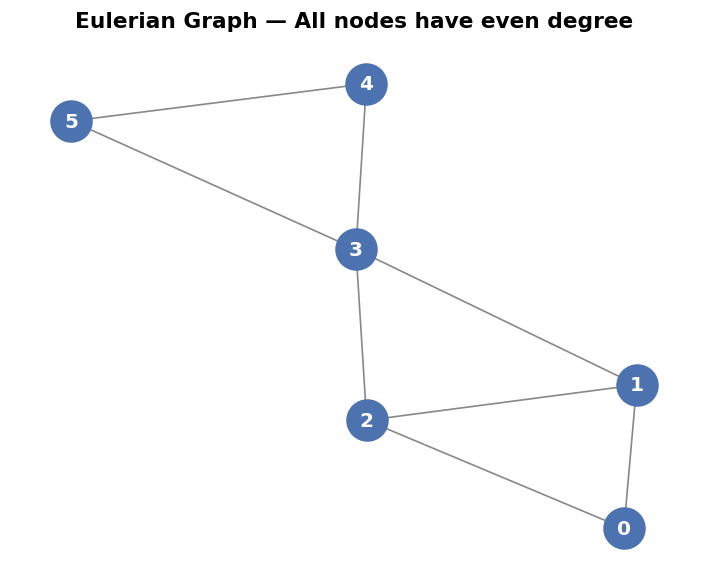

Degree of each node:
  Node 0: degree 2  (even)
  Node 1: degree 3  (ODD)
  Node 2: degree 3  (ODD)
  Node 3: degree 4  (even)
  Node 4: degree 2  (even)
  Node 5: degree 2  (even)

Odd-degree nodes : [1, 2] (2 total)
Eulerian Circuit : ✗ No
Eulerian Path    : ✓ Yes
Path             : 1 → 0 → 2 → 1 → 3 → 4 → 5 → 3


(False, True)

In [22]:
G_euler = create_eulerian_graph()

fig, ax = plt.subplots(figsize=(6, 5))
draw_simple_graph(G_euler, title='Eulerian Graph — All nodes have even degree', ax=ax)
plt.tight_layout()
plt.show()

print('Degree of each node:')
for node, deg in G_euler.degree():
    print(f'  Node {node}: degree {deg}  ({"even" if deg % 2 == 0 else "ODD"})')

print()
check_eulerian(G_euler)

---
<a id='section-8'></a>
## Section 8 — Maximal Cliques, Connectivity & Bridges

### Cliques
A **clique** is a set of nodes where every pair is connected — a fully connected subgraph.  
A **maximal clique** cannot be extended by adding any other node.

Cliques often correspond to social groups or functional modules.

In [23]:
K = create_karate_club_graph()
print_clique_info(K)

largest = find_largest_clique(K)
print(f'\nLargest clique: {sorted(largest)} (size {len(largest)})')

Number of maximal cliques : 36
  Clique 1: [0, 1, 2, 3, 13]  (size 5)
  Clique 2: [0, 1, 2, 3, 7]  (size 5)
  Clique 3: [8, 30, 32, 33]  (size 4)
  Clique 4: [23, 29, 32, 33]  (size 4)
  Clique 5: [0, 1, 17]  (size 3)
  Clique 6: [0, 1, 19]  (size 3)
  Clique 7: [0, 1, 21]  (size 3)
  Clique 8: [0, 4, 10]  (size 3)
  Clique 9: [0, 4, 6]  (size 3)
  Clique 10: [0, 5, 10]  (size 3)
  Clique 11: [0, 5, 6]  (size 3)
  Clique 12: [0, 2, 8]  (size 3)
  Clique 13: [0, 3, 12]  (size 3)
  Clique 14: [2, 8, 32]  (size 3)
  Clique 15: [5, 6, 16]  (size 3)
  Clique 16: [14, 32, 33]  (size 3)
  Clique 17: [15, 32, 33]  (size 3)
  Clique 18: [18, 32, 33]  (size 3)
  Clique 19: [20, 32, 33]  (size 3)
  Clique 20: [22, 32, 33]  (size 3)
  Clique 21: [31, 32, 33]  (size 3)
  Clique 22: [26, 29, 33]  (size 3)
  Clique 23: [23, 27, 33]  (size 3)
  Clique 24: [28, 31, 33]  (size 3)
  Clique 25: [24, 25, 31]  (size 3)
  Clique 26: [0, 11]  (size 2)
  Clique 27: [0, 31]  (size 2)
  Clique 28: [1, 30]  (size

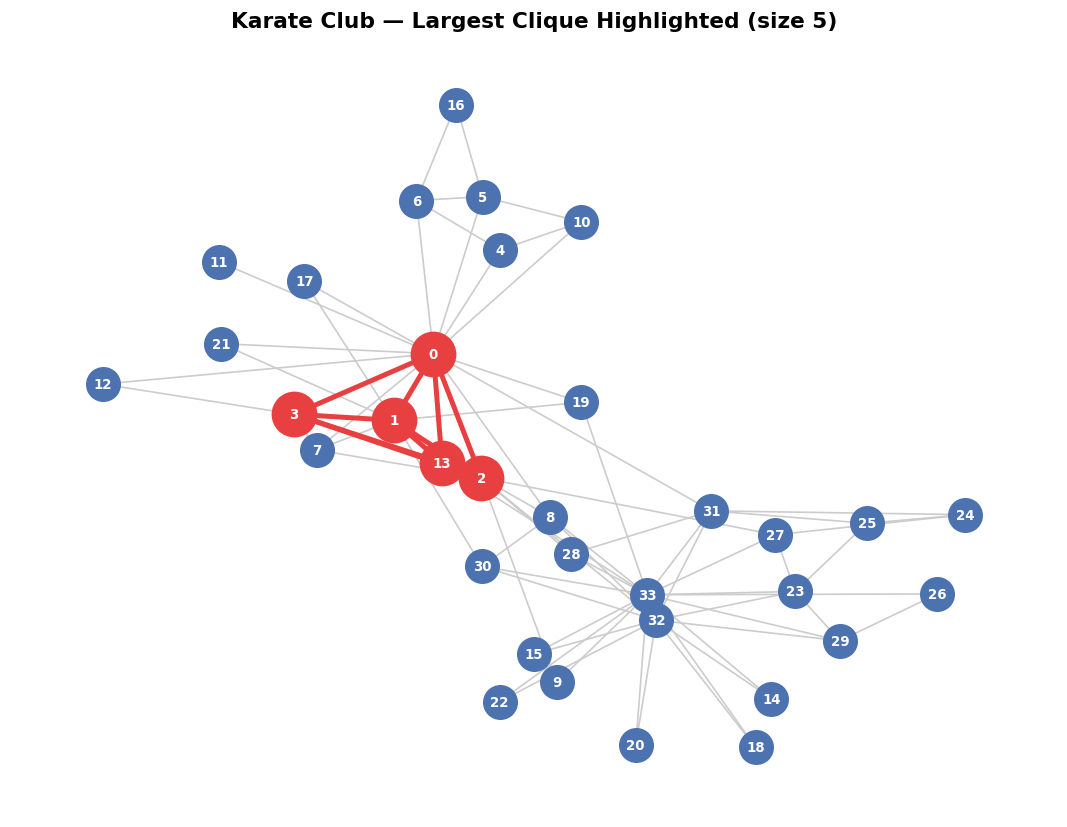

In [24]:
# Visualise the largest clique highlighted
fig, ax = plt.subplots(figsize=(9, 7))
pos = nx.spring_layout(K, seed=42)

non_clique = [n for n in K.nodes() if n not in largest]
clique_edges = [(u, v) for u, v in K.edges()
                if u in largest and v in largest]
other_edges  = [(u, v) for u, v in K.edges()
                if (u, v) not in clique_edges]

nx.draw_networkx_nodes(K, pos, nodelist=non_clique,
                       node_color='#4C72B0', node_size=400, ax=ax)
nx.draw_networkx_nodes(K, pos, nodelist=largest,
                       node_color='#E84040', node_size=700, ax=ax)
nx.draw_networkx_edges(K, pos, edgelist=other_edges,
                       edge_color='#ccc', ax=ax)
nx.draw_networkx_edges(K, pos, edgelist=clique_edges,
                       edge_color='#E84040', width=3, ax=ax)
nx.draw_networkx_labels(K, pos, font_size=8, font_color='white',
                        font_weight='bold', ax=ax)

ax.set_title(f'Karate Club — Largest Clique Highlighted (size {len(largest)})',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig("../images/karate_club_largest_clique.png")
plt.show()

### 8.1 — Edge Connectivity & Bridges

In [25]:
# Use the bridge graph from Section 6
G_bridge = create_two_cliques_with_bridge()

print('=== Connectivity Analysis ===')
print(f'Edge connectivity : {nx.edge_connectivity(G_bridge)}')
print(f'  (Minimum edges to remove to disconnect the graph)')
print()
print('=== Bridge Detection ===')
print(f'Bridge edges      : {find_bridges(G_bridge)}')
print(f'Articulation pts  : {find_articulation_points(G_bridge)}')

=== Connectivity Analysis ===
Edge connectivity : 1
  (Minimum edges to remove to disconnect the graph)

=== Bridge Detection ===
Bridge edges      : [(4, 5)]
Articulation pts  : [5, 4]


Removed edge: (4, 5)
Components before removal: 1
Components after  removal: 2
  ⚠ This was a bridge — graph is now disconnected!


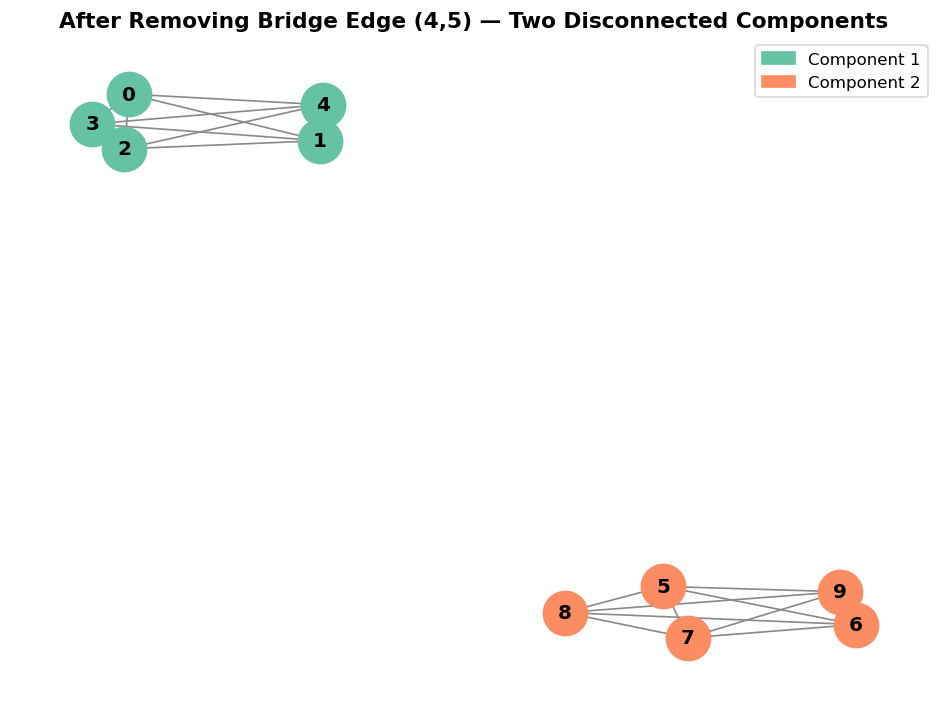

In [26]:
# Remove bridge and visualise disconnection
G_disconnected = remove_edge_and_check(G_bridge, (4, 5))
draw_components(G_disconnected,
                title='After Removing Bridge Edge (4,5) — Two Disconnected Components')

---
<a id='section-9'></a>
## Section 9 — Spanning Trees & Connected Components

### Spanning Tree
A **spanning tree** of a connected graph $G$ is a subgraph that:
- Includes **all nodes**
- Has **no cycles**
- Is **connected**
- Has exactly $n - 1$ edges

### Minimum Spanning Tree (MST)
For weighted graphs, the **MST** is the spanning tree with the minimum total edge weight.  
Algorithms: **Kruskal's** (sort edges by weight) or **Prim's** (grow from a seed node).

**Applications:** Network design, clustering, approximation algorithms.

Original graph : 6 nodes, 9 edges
MST            : 6 nodes, 5 edges
MST total weight : 26
MST edges: [(0, 1, 2), (0, 3, 6), (1, 2, 3), (1, 4, 5), (4, 5, 10)]


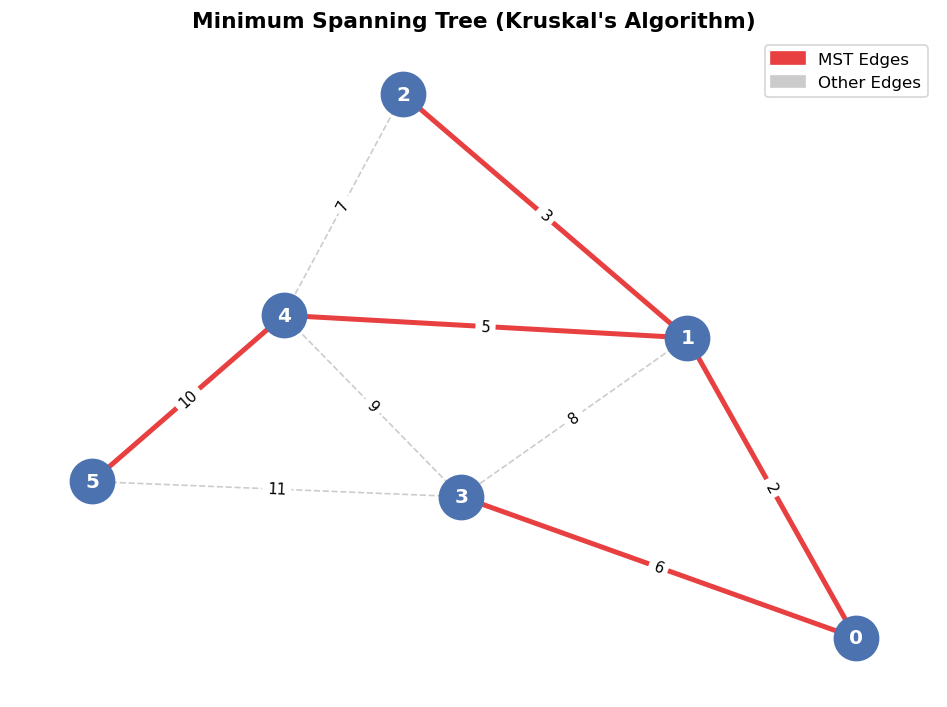

In [27]:
G_span = create_spanning_tree_graph()

# Compute MST using Kruskal's algorithm
T = nx.minimum_spanning_tree(G_span, algorithm='kruskal')

print(f'Original graph : {G_span.number_of_nodes()} nodes, {G_span.number_of_edges()} edges')
print(f'MST            : {T.number_of_nodes()} nodes, {T.number_of_edges()} edges')
print(f'MST total weight : {sum(d["weight"] for u, v, d in T.edges(data=True))}')
print(f'MST edges: {list(T.edges(data="weight"))}')

draw_spanning_tree(G_span, T, title='Minimum Spanning Tree (Kruskal\'s Algorithm)')

### 9.1 — Connected Components

Number of connected components: 3
  Component 1: [3, 4, 5, 6]
  Component 2: [0, 1, 2]
  Component 3: [7, 8, 9]


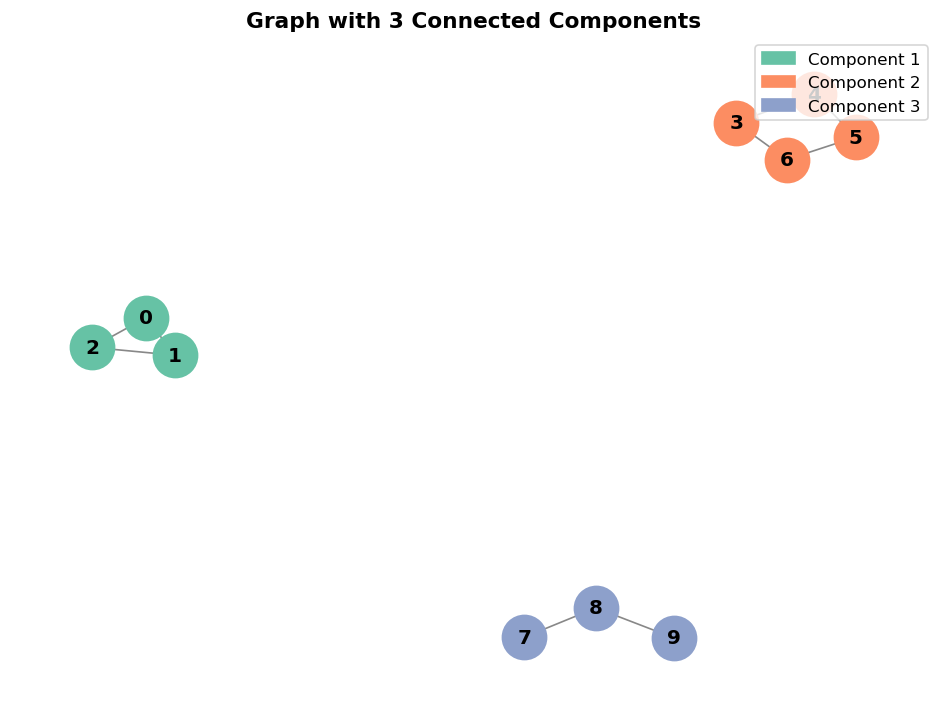

In [28]:
# Build a graph with 3 explicit components
G_multi = nx.Graph()
G_multi.add_edges_from([(0,1),(1,2),(0,2)])          # Component 1 (triangle)
G_multi.add_edges_from([(3,4),(4,5),(5,6),(3,6)])    # Component 2 (square)
G_multi.add_edges_from([(7,8),(8,9)])                # Component 3 (path)

components = get_connected_components(G_multi)
print(f'Number of connected components: {len(components)}')
for i, comp in enumerate(components, 1):
    print(f'  Component {i}: {sorted(comp)}')

draw_components(G_multi, title='Graph with 3 Connected Components')

---
## Summary

| Section | Key Concepts |
|---|---|
| 1 | Graph types: undirected, directed, weighted, multi |
| 2 | Adjacency, Degree, Laplacian matrices; $L = D - A$ |
| 3 | Node/edge queries, degrees, neighbours, adjacency list |
| 4 | BFS (unweighted) and Dijkstra (weighted) shortest paths |
| 5 | Degree, closeness, betweenness, eigenvector centrality |
| 6 | Bridge edges, articulation points, community structure |
| 7 | Diameter, density, Eulerian circuits and paths |
| 8 | Maximal cliques, edge connectivity, bridges |
| 9 | Spanning trees, MST (Kruskal), connected components |

---
*Next notebook: Community Detection Algorithms (Louvain, Girvan-Newman, Spectral Clustering)*